# Tutorial for using the topwords module

This tutorial will guide on how to use this module for extracting keywords the `KeyTerms` class and topwords using the `ZTest` class

## Table of contents
- [`KeyTerms` Class](#textacy)
- [`ZTest` Class](#ztest)
- [Experimentation](#exp)
- [Making Wordclouds](#wordcloud)

## What's the Difference Between `KeyTerms` and `ZTest`?
Imagine you have a large collection of books.
### `KeyTerms` (Keywords for a Single Book):
Think of `Keyterms` as being like a "Table of Contents" or "Index" generator for one specific book.
- What it does: It looks inside that single book and identifies the most important words or phrases that tell you what that particular book is about. It doesn't compare it to anything else. It's focused on the most central themes within its own pages.
#### Use it when you want to: 
- Understand the main topics or keywords of a single document, email, article, or any piece of text in isolation. For example, if you want to know what "Dracula" is mostly about without comparing it to other novels.
- Example Output: You'll see phrases like "poor old man," "dear old man," or "good one" from Dracula. These are phrases that are highly connected and central to the plot or themes within that book itself.
### `ZTest` (Distinguishing Words Between Groups of Books):
Now, imagine you have two piles of books: one pile is your "special" pile (your target documents), and the other is your "general" pile (your background documents).
Think of `ZTest` as a "Distinguishing Features Finder" between these two piles.
- What it does: It compares the words and phrases in your "special" pile to those in your "general" pile. Its goal is to find words that are unusually common in your "special" pile compared to how common they are in the "general" pile, or vice-versa. It's about finding what makes your "special" pile unique.
#### Use it when you want to: 
- Identify terms that characterize a specific author's style compared to others.
- Find out what makes a particular genre of text different from a general corpus.
- See what words are most representative of a political speech compared to everyday conversation.
- Example Output: You'll see words like "Alice," "ROMEO," "thou," "thy," "thee" with large negative scores when Dracula is your target and "Alice in Wonderland" and "Romeo and Juliet" are your background. This tells you that words like "Alice" are much more likely to appear in the "background" books (Alice in Wonderland) than in your "target" book (Dracula), acting as strong distinguishing features for the background. If a word from Dracula was much more common in Dracula than in the other books, it would have a large positive Z-score.
### In short:
- `KeyTerms` = What is THIS document about? (Internal importance)
- `ZTest` = What makes THIS group of documents different from THAT group of documents? (Comparative distinctiveness)

### 1. The `KeyTerms` class
<a id='textacy'></a>
This class wraps Textacy's `extract.keyterms` method, the user is able to extract representative keywords from a single document, using the library's algorithms `textrank` or `sgrank`

__Parameters:__

- `document`: The raw text or spaCy Doc to analyze.
- `method`: `"textrank"` or `"sgrank"` (default: `"textrank"`).
- `topn`: Number of top keywords to return (default: 10).
- `tokenizer`: (optional) A `Tokenizer` instance.
- `model`: (optional) The spaCy model being used for tokenization (defaults to `en_core_web_sm`)
- `ngrams`: Specifies the range of n-grams (contiguous sequences of n words) to consider as candidate topwords.
- `normalize`: Normalization for keyterm extraction (e.g., 'lemma', 'lower', or None).


In [2]:
from lexos.topwords.keyterms import KeyTerms
from lexos.io.loader import Loader
import spacy

nlp = spacy.load("en_core_web_sm")  # or another full English model

loader = Loader()

file_path = "txt_files/Dracula by Bram Stoker.txt"

loader.load([file_path])

try:
    dracula_text = loader.texts[0]
    dracula_doc = nlp(dracula_text)

    key_terms = KeyTerms(
        document=dracula_doc,
        method="textrank",
        topn=5,
        model="en_core_web_sm",
        ngrams=(1, 3),
        normalize="lemma", # Added normalize parameter
    )
    result = key_terms()  # Run the analysis

    print(key_terms.to_dict())  # output: list of dicts
    print("=" * 100)
    print(key_terms.to_df())  # output: pandas dataframe
    print("=" * 100)
    print(key_terms.to_list())  # output: list of tuples
except (IndexError, AttributeError):
    print("File could not be loaded. Please check the file path and try again.")
    print("Errors:", loader.errors)


{'keywords': [{'term': 'poor old man', 'score': 0.003206022699175089}, {'term': 'dear old man', 'score': 0.003024587536594135}, {'term': 'good one', 'score': 0.0028979297601152325}, {'term': 'little one', 'score': 0.002790966705387591}, {'term': 'good brave man', 'score': 0.002725431504644253}]}
             term     score
0    poor old man  0.003206
1    dear old man  0.003025
2        good one  0.002898
3      little one  0.002791
4  good brave man  0.002725
[('poor old man', 0.003206022699175089), ('dear old man', 0.003024587536594135), ('good one', 0.0028979297601152325), ('little one', 0.002790966705387591), ('good brave man', 0.002725431504644253)]


### Understanding `TextacyKeywords` Output
The `TextacyKeywords` output, whether as a DataFrame or a list of tuples, provides a term and a score.
For example:
```
term score
0 poor old man 0.003206
1 dear old man 0.003025
2 good one 0.002898
3 little one 0.002791
4 good brave man 0.002725
```
- `term`: This represents the keyword or keyphrase extracted from the document. `TextacyKeywords` uses algorithms like TextRank, which are graph-based methods that identify important words or phrases by analyzing their relationships within the text. This is why you often see multi-word phrases like "poor old man" or "good brave man" as keywords.
- `score`: This is a numerical value indicating the estimated importance or salience of the term within the single document being analyzed. A higher score means the algorithm considers that term more central or relevant to the document's content. For example, 'poor old man' is more relevant to the document's content than 'good brave man'. The exact range and meaning of the score depend on the specific Textacy algorithm used (textrank or sgrank), but generally, they are normalized values, not counts or frequencies. They reflect the term's position and connections in the text's semantic network. 
#### In essence, this output tells you what phrases are most characteristic of this specific document.

### 2. The `ZTest` class<a id='ztest'></a>

This class implements the Z-Test based topwords extraction, allowing users to identify statistically significant keywords that distinguish a set of target texts from a background corpus.

__Parameters:__

- `target_documents`: List of target documents (strings or spaCy Docs).
- `background_documents`: List of background documents (strings or spaCy Docs).
- `topn`: Number of top words to return (default: 10).
- `ngrams`: Tuple specifying the ngram range, e.g., `(1, 1)` for unigrams only (default: `(1, 1)`).
- `case_sensitive`, `remove_stopwords`, `remove_punct`, `remove_digits`: Preprocessing options.
- `model`: spaCy model name to use for tokenization (default: `"en_core_web_sm"`).
- `tokenizer`: (optional) A `Tokenizer` instance.
- `docs`: (optional) List of spaCy `Doc` objects to set results on.
- `output_format`: Output format: `"dict"`, `"dataframe"`, `"list_of_dicts"`, or `"list_of_tuples"` (default: `"dict"`).


In [3]:
from lexos.topwords.ztest import ZTest
from lexos.io.loader import Loader

# List the specific files you want
txt_paths = [
    "txt_files/Alices Adventures in Wonderland by Lewis Carroll.txt",
    "txt_files/Romeo and Juliet by William Shakespeare.txt",
]

# Load the files
loader = Loader()
loader.load(txt_paths)

# The texts are now in loader.texts
background_texts = loader.texts

target_texts = [dracula_text] # Using dracula_text from previous cell

# Use the already defined target_texts (a list of strings)
ztest = ZTest(
    target_documents=target_texts, background_documents=background_texts
)
ztest()  # Run the analysis
print(ztest.to_dict())  # List of dicts
print("=" * 100)
print(ztest.to_df())  # DataFrame
print("=" * 100)
print(ztest.to_list())  # List of tuples
# Each doc in docs now has doc._.topwords set to the top words

{'topwords': [{'term': 'Alice', 'z_score': -33.4219511501216}, {'term': 'thou', 'z_score': -25.662544359995007}, {'term': 'ROMEO', 'z_score': -21.584175665545136}, {'term': 'Romeo', 'z_score': -20.591338393482452}, {'term': 'O', 'z_score': -20.591338393482452}, {'term': 'thy', 'z_score': -20.52344643281519}, {'term': 'thee', 'z_score': -19.54828296003112}, {'term': 'And', 'z_score': -19.34349183430946}, {'term': 'JULIET', 'z_score': -18.446492555511764}, {'term': 'she', 'z_score': -17.869720598323884}]}
     term    z_score
0   Alice -33.421951
1    thou -25.662544
2   ROMEO -21.584176
3   Romeo -20.591338
4       O -20.591338
5     thy -20.523446
6    thee -19.548283
7     And -19.343492
8  JULIET -18.446493
9     she -17.869721
[('Alice', -33.4219511501216), ('thou', -25.662544359995007), ('ROMEO', -21.584175665545136), ('Romeo', -20.591338393482452), ('O', -20.591338393482452), ('thy', -20.52344643281519), ('thee', -19.54828296003112), ('And', -19.34349183430946), ('JULIET', -18.446

### Understanding `ZTest` Output
The `ZTest` output provides a term and a z_score.
For example:
```
term z_score
0 Alice -30.694384
1 thou -23.555131
2 ROMEO -19.807056
3 Romeo -18.895006
4 O -18.895006
5 thy -18.832643
6 thee -17.936969
7 JULIET -16.925139
8 CAPULET -15.321415
9 NURSE -14.614962
```
- `term`: This is a word or phrase (n-gram) that has a statistically significant difference in its relative frequency between your target_documents and your background_documents.
- `z_score`: This is the result of a Z-test, which measures the statistical significance of the difference in proportions of a given term between the two document sets.
#### Magnitude of the Z-score
- The larger the absolute value of the Z-score, the more statistically significant the difference in frequency. A Z-score further from zero (either very high positive or very high negative) indicates a stronger distinction.
#### Sign of the Z-score:
- Negative Z-score (e.g., Alice, ROMEO, thou): This indicates that the term is more characteristic of the background_documents (in this case, Alice in Wonderland and Romeo and Juliet) compared to the target_documents (in this case, Dracula). The higher the absolute negative value, the more strongly that term belongs to the background set.
- Positive Z-score: (You might not see many in this example if Dracula is truly distinct from the background). A positive Z-score would indicate that the term is more characteristic of the target_documents compared to the background_documents. This is often what users are looking for when identifying "top distinguishing words."

The Z-test helps filter out common words that appear equally frequently in both sets, focusing instead on terms that truly distinguish one corpus from another. In your example, words like "Alice," "ROMEO," "thou," "thy," "thee," "JULIET," "CAPULET," and "NURSE" are all highly characteristic of the background Shakespeare plays, and "Alice" of Alice in Wonderland, explaining their large negative Z-scores when Dracula is the target. If "Dracula" (the word) were common in the target and rare in the background, it would likely have a large positive Z-score if it were included (or a very negative score if the target was the background and background was the target).

### 3. Example Experiments with the `topwords` Module


- **Extracting representative keywords from a single literary work**  
    Use `KeyTerms` to identify the most important terms or phrases in a novel, article, or essay.

- **Comparing distinguishing words between two or more texts**  
    Use `ZTest` to find words that are statistically significant in one document (or set) compared to a background corpus.

- **Analyzing topic drift across chapters or sections**  
    Apply `KeyTerms` or `ZTest` to different segments of a text to observe how key terms change over time.

- **Identifying authorial style or signature vocabulary**  
    Compare works by different authors to find words or phrases that are characteristic of each.

- **Studying the effect of preprocessing choices**  
    Experiment with parameters like `remove_stopwords`, `remove_punct`, `ngrams`, and `case_sensitive` to see how they affect the output.

- **Building custom keyword extraction pipelines**  
    Integrate the module with other NLP tools (e.g., sentiment analysis, entity recognition) for richer text analysis.

- **Exploring genre or period-specific vocabulary**  
    Use the Z-test approach to compare texts from different genres or historical periods.

- **Evaluating the impact of different spaCy models**  
    Swap out the `model` parameter to see how different language models affect tokenization and keyword extraction.

- **Extracting representative keywords from a single literary work**  
    Use `KeyTerms` to identify the most important terms or phrases in a novel, article, or essay.

- **Comparing distinguishing words between two or more texts**  
    Use `ZTest` to find words that are statistically significant in one document (or set) compared to a background corpus.

- **Analyzing topic drift across chapters or sections**  
    Apply `KeyTerms` or `ZTest` to different segments of a text to observe how key terms change over time.

- **Identifying authorial style or signature vocabulary**  
    Compare works by different authors to find words or phrases that are characteristic of each.

- **Studying the effect of preprocessing choices**  
    Experiment with parameters like `remove_stopwords`, `remove_punct`, `ngrams`, and `case_sensitive` to see how they affect the output.

- **Building custom keyword extraction pipelines**  
    Integrate the module with other NLP tools (e.g., sentiment analysis, entity recognition) for richer text analysis.

- **Exploring genre or period-specific vocabulary**  
    Use the Z-test approach to compare texts from different genres or historical periods.

- **Evaluating the impact of different spaCy models**  
    Swap out the `model` parameter to see how different language models affect tokenization and keyword extraction.

<a id='exp'></a>

### 4. Word Clouds 


A word cloud visually represents the frequency or importance of words. Larger words indicate higher significance. This is particularly useful for quickly grasping the most prominent keywords from `KeyTerms` or the distinguishing terms from `ZTest`. Our API provides a wordcloud() function to generate these visualizations.

### Customizing Word Clouds

 The `wordcloud()` function offers various options for customization, similar to the standalone Word Cloud tutorial:

 * `background_color`: Set the background color of the image.
 * `colormap`: Choose a color scheme for the words.
 * `max_words`: Limit the number of words displayed.
 * `mask`: Use a custom image to shape the word cloud.
 * `round`: Control the roundness of the word cloud shape.
 * `width`, `height`: Adjust the dimensions of the output image.
 * `font_path`: Specify a custom font.
 * `figure_opts`: Pass a dictionary of options to the underlying Matplotlib figure.

 Refer to the Lexos Word Cloud tutorial for more detailed customization examples.

#### Word Cloud from `KeyTerms` Output
You can directly use the output (as a list of tuples with term and score) from `KeyTerms` to generate a word cloud. The wordcloud() function can interpret this format. The 'score' from Textacy will determine the size of the words in the cloud.

In [6]:
%matplotlib inline

KeyTerms: Number of raw keywords extracted: 10
DataFrame for KeyTerms Word Cloud (head):
                   score
term                    
poor old man    0.003206
dear old man    0.003025
good one        0.002898
little one      0.002791
good brave man  0.002725
DataFrame shape: (10, 1)
Type of object returned by wordcloud: <class 'wordcloud.wordcloud.WordCloud'>
Shape of image array: (600, 800, 3)


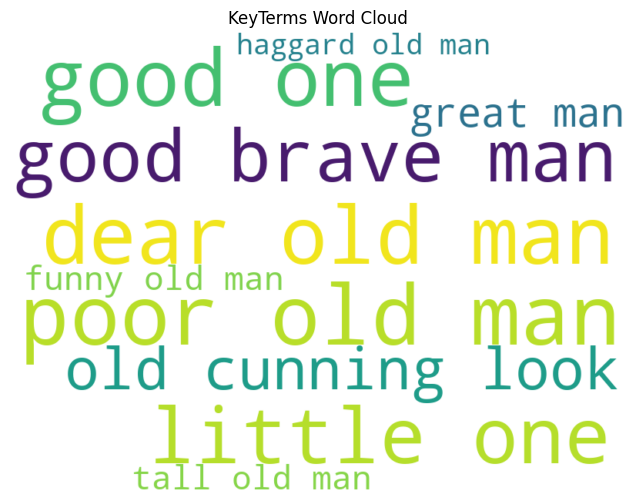

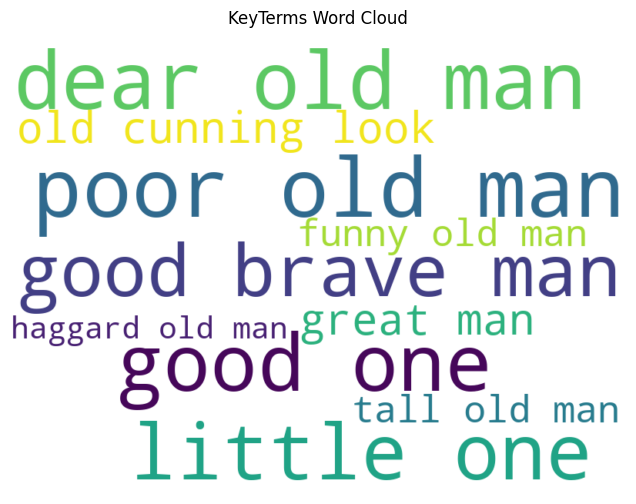

In [7]:
from lexos.visualization.cloud import wordcloud
from lexos.topwords.keyterms import KeyTerms # Updated import
from lexos.io.loader import Loader
import spacy
import pandas as pd
import matplotlib.pyplot as plt  # Import plt again if it's a separate cell for clarity

# Load spaCy model once
nlp = spacy.load("en_core_web_sm")

loader = Loader()
file_path = "txt_files/Dracula by Bram Stoker.txt"
loader.load([file_path])

try:
    dracula_text = loader.texts[0]
    dracula_doc = nlp(dracula_text)

    key_terms_obj = KeyTerms( # Changed variable name to avoid conflict
        document=dracula_doc,
        method="textrank",
        topn=10,
        model="en_core_web_sm",
        ngrams=(1, 3),
        normalize="lemma",
    )
    key_terms_obj()
    keywords_for_wc = key_terms_obj.to_list()

    print(f"KeyTerms: Number of raw keywords extracted: {len(keywords_for_wc)}")
    if not keywords_for_wc:
        print(
            "WARNING: No keywords extracted by KeyTerms. Word Cloud will be empty."
        )
        raise ValueError("No keywords to display for KeyTerms.")

    keywords_df = pd.DataFrame(keywords_for_wc, columns=["term", "score"]).set_index(
        "term"
    )
    print("DataFrame for KeyTerms Word Cloud (head):")
    print(keywords_df.head())
    print(f"DataFrame shape: {keywords_df.shape}")
    if keywords_df.empty:
        print(
            "WARNING: DataFrame for KeyTerms is empty. Word Cloud will be empty."
        )
        raise ValueError("Empty DataFrame for KeyTerms.")

    wc_object = wordcloud(
        keywords_df,
        opts={
            "colormap": "viridis",
            "background_color": "white",
            "width": 800,
            "height": 600,
            "max_words": 50,
            "prefer_horizontal": 0.9,
        },
        show=False,
    )

    print(f"Type of object returned by wordcloud: {type(wc_object)}")
    if not hasattr(wc_object, "to_array"):
        print(
            "ERROR: wordcloud function did not return a WordCloud object with .to_array() method."
        )
        print("It returned:", wc_object)
        raise TypeError("Unexpected return type from wordcloud function.")

    image_array = wc_object.to_array()
    print(f"Shape of image array: {image_array.shape}")
    if image_array.size == 0:
        print(
            "WARNING: Generated image array is empty. This means no words were plotted."
        )
        raise ValueError("Empty image generated by wordcloud.")

    plt.figure(figsize=(8, 6))
    plt.imshow(image_array, interpolation="bilinear")
    plt.axis("off")
    plt.title("KeyTerms Word Cloud")
    plt.show()

except (IndexError, AttributeError, ValueError, TypeError) as e:
    print(f"An error occurred during KeyTerms Word Cloud generation: {e}")
    print(
        "Please ensure 'Dracula by Bram Stoker.txt' is in 'txt_files/' and contains sufficient text."
    )
    if "loader" in locals() and hasattr(loader, "errors"):
        print("Errors during loading:", loader.errors)

print("\n" + "=" * 50 + "\n")  # Separator for clarity

##### Word Cloud from `ZTest` Output
<a id='wordcloud'></a>
 Similarly, you can create a word cloud from the `ZTest` output. In this case, the absolute value of the Z-score can determine the size of the words, indicating how strongly the term distinguishes the target from the background corpus.


ZTest: Number of raw topwords extracted: 15
DataFrame for ZTest Word Cloud (head):
        abs_z_score
term               
alice     33.505551
romeo     29.841390
thou      27.855220
juliet    23.265056
thy       21.777327
DataFrame shape: (15, 1)
Type of object returned by wordcloud (ZTest): <class 'wordcloud.wordcloud.WordCloud'>
Shape of image array (ZTest): (800, 1000, 3)


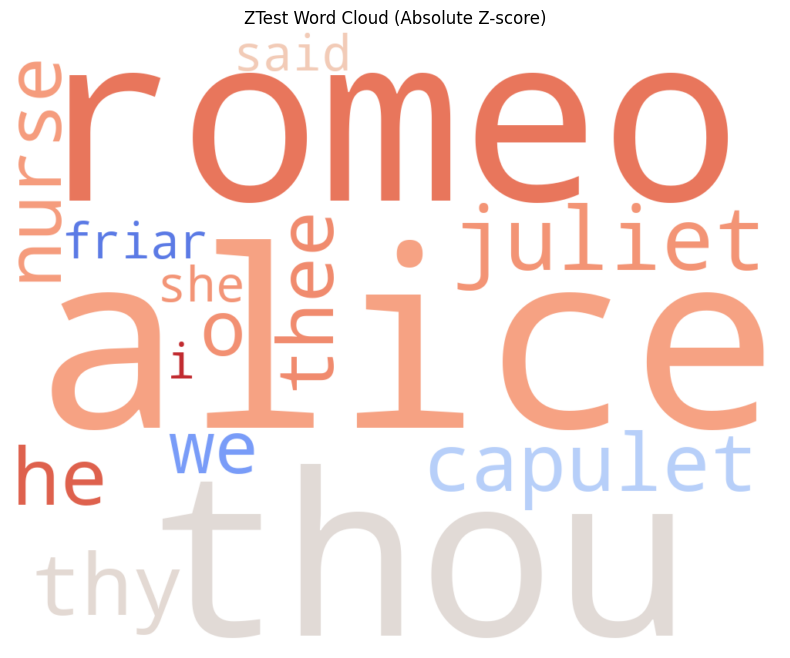

In [8]:
from lexos.topwords.ztest import ZTest # Updated import
from lexos.io.loader import Loader
from lexos.visualization.cloud import wordcloud
import matplotlib.pyplot as plt
import pandas as pd  # Make sure pandas is imported here too

loader = Loader()
txt_paths = [
    "txt_files/Alices Adventures in Wonderland by Lewis Carroll.txt",
    "txt_files/Romeo and Juliet by William Shakespeare.txt",
]
loader.load(txt_paths)
background_texts = loader.texts

try:
    # Assuming dracula_text is still available from the previous cell or re-load it
    if "dracula_text" not in locals():
        loader_dracula = Loader()
        loader_dracula.load(["txt_files/Dracula by Bram Stoker.txt"])
        dracula_text = loader_dracula.texts[0]

    target_texts = [dracula_text]

    ztest_obj = ZTest( # Changed variable name to avoid conflict
        target_documents=target_texts,
        background_documents=background_texts,
        topn=15,  # More topwords for the cloud
        remove_stopwords=True,
        remove_punct=True,
        case_sensitive=False,
    )
    ztest_obj()
    topwords_for_wc = ztest_obj.to_list()

    print(f"ZTest: Number of raw topwords extracted: {len(topwords_for_wc)}")
    if not topwords_for_wc:
        print(
            "WARNING: No topwords extracted by ZTest. Word Cloud will be empty."
        )
        raise ValueError("No topwords to display for ZTest.")

    # Convert list of tuples to a Pandas DataFrame
    # Use absolute Z-score for size, as the sign doesn't affect visual size directly.
    ztest_df = pd.DataFrame(
        [(term, abs(score)) for term, score in topwords_for_wc],
        columns=["term", "abs_z_score"],
    ).set_index("term")

    print("DataFrame for ZTest Word Cloud (head):")
    print(ztest_df.head())
    print(f"DataFrame shape: {ztest_df.shape}")
    if ztest_df.empty:
        print(
            "WARNING: DataFrame for ZTest is empty. Word Cloud will be empty."
        )
        raise ValueError("Empty DataFrame for ZTest.")

    wc_object_ztest = wordcloud(
        ztest_df,  # Pass the DataFrame
        opts={
            "colormap": "coolwarm",  # A diverging colormap
            "background_color": "white",
            "width": 1000,
            "height": 800,
            "max_words": 75,  # Adjust max words for ztest
            "prefer_horizontal": 0.9,
        },
        show=False,
    )

    print(f"Type of object returned by wordcloud (ZTest): {type(wc_object_ztest)}")
    if not hasattr(wc_object_ztest, "to_array"):
        print(
            "ERROR: wordcloud function did not return a WordCloud object with .to_array() method for ZTest."
        )
        print("It returned:", wc_object_ztest)
        raise TypeError("Unexpected return type from wordcloud function for ZTest.")

    image_array_ztest = wc_object_ztest.to_array()
    print(f"Shape of image array (ZTest): {image_array_ztest.shape}")
    if image_array_ztest.size == 0:
        print(
            "WARNING: Generated image array is empty for ZTest. This means no words were plotted."
        )
        raise ValueError("Empty image generated by wordcloud for ZTest.")

    plt.figure(figsize=(10, 8))
    plt.imshow(image_array_ztest, interpolation="bilinear")
    plt.axis("off")
    plt.title("ZTest Word Cloud (Absolute Z-score)")
    plt.show()

except (IndexError, AttributeError, ValueError, TypeError) as e:
    print(f"An error occurred during ZTest Word Cloud generation: {e}")
    print(
        "Please ensure all necessary files are in 'txt_files/' and contain sufficient text."
    )
    if "loader" in locals() and hasattr(loader, "errors"):
        print("Errors during loading:", loader.errors)